# People Analytics: EDA y Clustering de Colaboradores

Este notebook realiza el análisis exploratorio de datos (EDA) y la segmentación de colaboradores mediante técnicas de Machine Learning para optimizar la asignación de proveedores de capacitación PCI DSS.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn_som.som import SOM
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## 1. Carga de Datos

In [2]:
df = pd.read_csv('../data/dataset_entrada.csv')
print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (5000, 22)


,Employee_ID,Department,Gender,Age,Education_Level,Job_Role,Monthly_Income,Years_At_Company,Years_In_Current_Role,Job_Satisfaction,...,Training_Hours_Last_Year,Last_Promotion_Years_Ago,Distance_From_Home,Overtime,Attrition,Marital_Status,Number_Of_Companies_Worked,Stock_Option_Level,Employee_ID_Custom,resultado_capacitacion_pci
0,1001.0,Sales,Female,28.0,Bachelor's Degree,Analyst,3822.0,23.0,0.0,3.0,...,24.0,3.0,29.0,Yes,No,Married,7.0,2.0,1,76
1,1002.0,Marketing,Female,36.0,Master's Degree,Manager,10125.0,31.0,11.0,1.0,...,61.0,1.0,14.0,No,Yes,Divorced,8.0,0.0,2,84
2,1003.0,Finance,Non-binary,28.0,PhD,Analyst,3256.0,33.0,12.0,3.0,...,83.0,11.0,2.0,Yes,Yes,Divorced,7.0,3.0,3,64
3,1004.0,Marketing,Male,18.0,High School,Intern,1279.0,0.0,0.0,3.0,...,0.0,0.0,48.0,Yes,No,Single,1.0,0.0,4,99
4,1005.0,Marketing,Non-binary,55.0,Bachelor's Degree,Team Lead,8221.0,1.0,4.0,1.0,...,1.0,7.0,22.0,Yes,No,Divorced,9.0,3.0,5,81


## 2. Análisis Exploratorio de Datos (EDA)

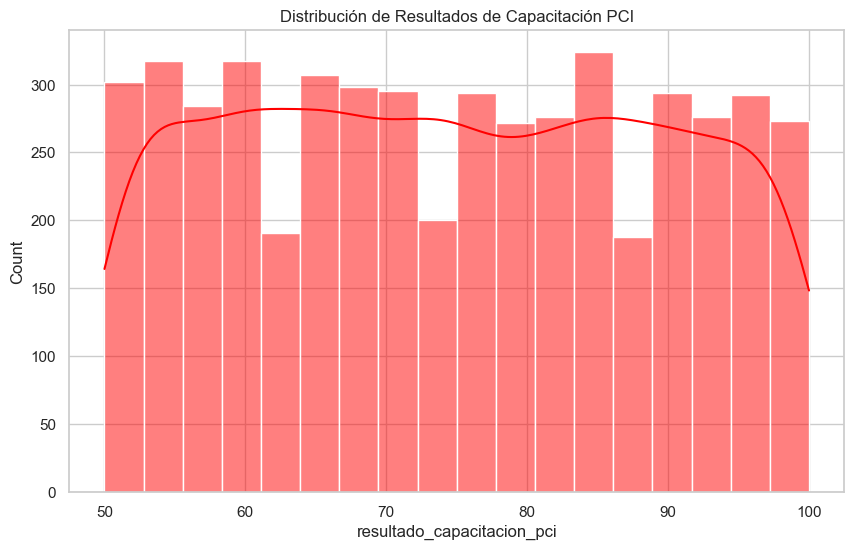

In [3]:
# Distribución del Resultado de Capacitación PCI
plt.figure(figsize=(10, 6))
sns.histplot(df['resultado_capacitacion_pci'], kde=True, color='red')
plt.title('Distribución de Resultados de Capacitación PCI')
plt.show()

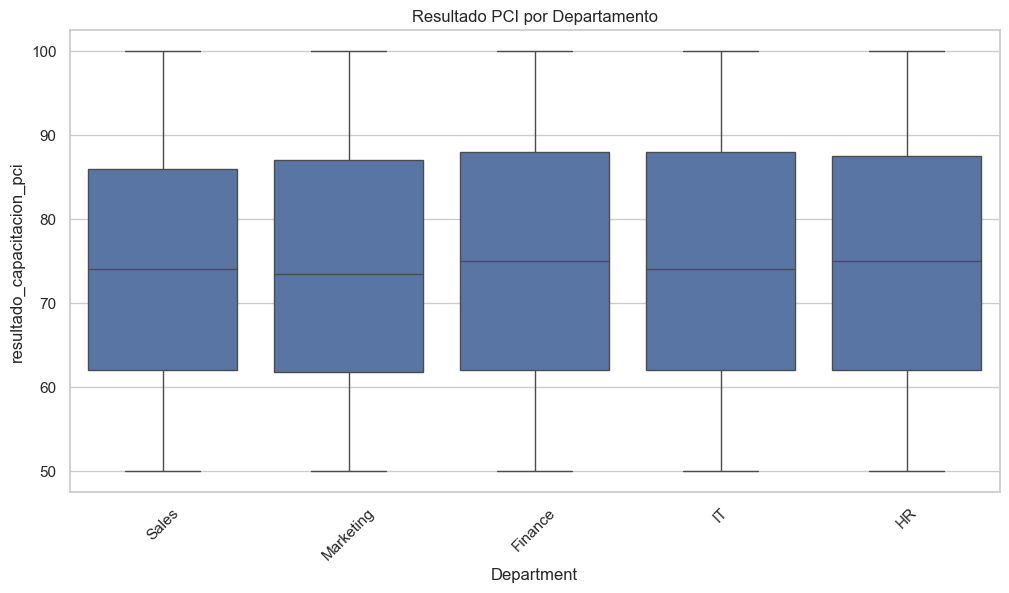

In [4]:
# Relación entre Departamento y Resultado PCI
plt.figure(figsize=(12, 6))
sns.boxplot(x='Department', y='resultado_capacitacion_pci', data=df)
plt.xticks(rotation=45)
plt.title('Resultado PCI por Departamento')
plt.show()

## 3. Preprocesamiento para Clustering

In [5]:
# Selección de variables para el modelo
# Excluimos IDs y variables que no aportan a la segmentación demográfica/laboral
cols_to_drop = ['Employee_ID', 'Employee_ID_Custom', 'resultado_capacitacion_pci']
features = df.drop(columns=cols_to_drop)

# Codificación de variables categóricas
le = LabelEncoder()
for col in features.select_dtypes(include=['object']).columns:
    features[col] = le.fit_transform(features[col].astype(str))

# Escalado de variables
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

## 4. Modelado de Clustering

In [6]:
def evaluate_clustering(name, labels, data):
    sil = silhouette_score(data, labels)
    ch = calinski_harabasz_score(data, labels)
    db = davies_bouldin_score(data, labels)
    return {'Algoritmo': name, 'Silueta': sil, 'CH': ch, 'Davies-Bouldin': db}

n_clusters = 3 # Basado en la cantidad de proveedores
results = []

# 1. K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(features_scaled)
results.append(evaluate_clustering('K-Means', kmeans_labels, features_scaled))

# 2. Hierarchical Clustering (Ward)
hierarchical = AgglomerativeClustering(n_clusters=n_clusters)
hier_labels = hierarchical.fit_predict(features_scaled)
results.append(evaluate_clustering('Hierarchical', hier_labels, features_scaled))

# 3. Self-Organizing Maps (SOM)
# Nota: Usamos una grilla simple para obtener clusters
som = SOM(m=3, n=1, dim=features_scaled.shape[1], random_state=42)
som.fit(features_scaled)
som_labels = som.predict(features_scaled)
results.append(evaluate_clustering('SOM', som_labels, features_scaled))

df_results = pd.DataFrame(results)
df_results

,Algoritmo,Silueta,CH,Davies-Bouldin
0,K-Means,0.134402,706.658715,2.583299
1,Hierarchical,0.130001,686.592621,2.657982
2,SOM,0.128907,676.943057,2.677221


## 5. Selección y Exportación

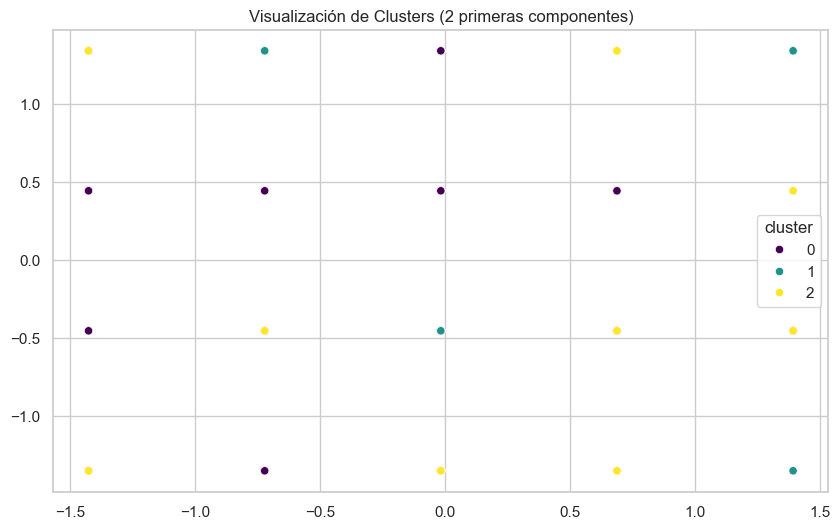

Archivo data/dataset_salida.csv generado con éxito.


In [7]:
# Seleccionamos el mejor modelo (ej: K-Means por balance de métricas)
df['cluster'] = kmeans_labels

# Visualización de los clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=features_scaled[:, 0], y=features_scaled[:, 1], hue=df['cluster'], palette='viridis')
plt.title('Visualización de Clusters (2 primeras componentes)')
plt.show()

# Guardar resultados
df.to_csv('../data/dataset_salida.csv', index=False)
print("Archivo data/dataset_salida.csv generado con éxito.")